# 1.1 Preprocessamento: Data Cleaning

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset_incendi.txt", sep=" ")

df.describe()

,umidità,temperatura,co2,tvoc,classe
count,1083.000000,1083.000000,1083.000000,1083.000000,1083.000000
mean,54.111727,25.130933,1661.255771,1030.929825,0.117267
std,12.655666,4.235253,1491.438146,2690.497950,0.321887
min,22.000000,22.700000,400.000000,0.000000,0.000000
25%,41.000000,23.200000,799.500000,60.500000,0.000000
50%,58.000000,23.700000,1494.000000,168.000000,0.000000
75%,60.000000,24.100000,1720.000000,357.000000,0.000000
max,95.000000,41.600000,10481.000000,18849.000000,1.000000


Il numero di istanze è 1083. Da questo report riassuntivo è possibile notare come alcune feature tipo co2 e tvoc abbiano una varianza molto alta, segnale di feature molto eterogenee. Di conseguenza, per queste classi è più probabile trovare outliers. Eseguo una verifica per confermare.

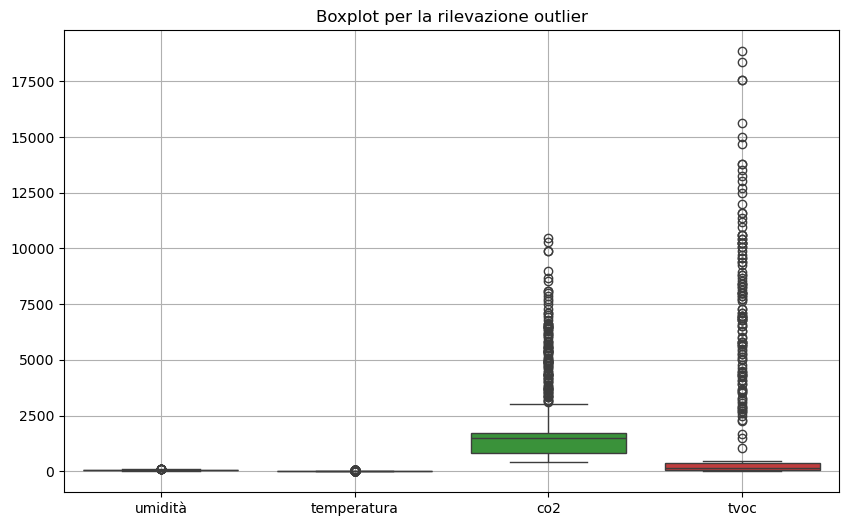

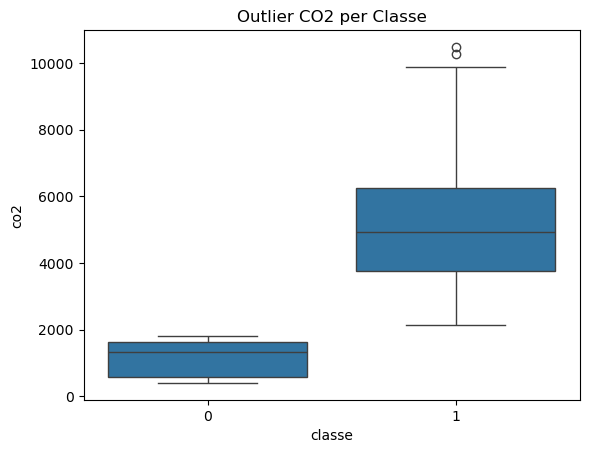

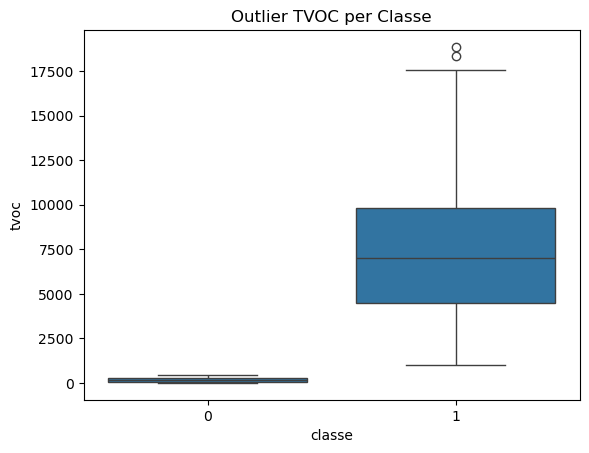

In [4]:
df.describe().transpose()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['umidità', 'temperatura', 'co2', 'tvoc']])
plt.title("Boxplot per la rilevazione outlier")
plt.grid(True)
plt.show()


sns.boxplot(x='classe', y='co2', data=df)
plt.title("Outlier CO2 per Classe")
plt.show()

sns.boxplot(x='classe', y='tvoc', data=df)
plt.title("Outlier TVOC per Classe")
plt.show()

Come si può notare dai box-plot, gli outlier rilevati non sono necessariamente errori, dal momento che sono essenziali per distinguere la classe 1 dalla classe 0. Comunque, possono influenzare negativamente modelli sensibili alla scala come il KNN. Tuttavia, con uno scaling di tipo ROBUST o log-transform, è possibile mitigare questo effetto.

In [5]:
# CI SONO DEI MISSING VALUE?

bool_ds = df.isnull()
nan_per_column = bool_ds.sum(axis=0)

# CONTO I NAN PER OGNI COLONNA
print(nan_per_column)
total_nan = nan_per_column.sum()
print(f"In totale, ci sono {total_nan} valori NaN.")

# STAMPO LE RIGHE CON DEI NAN
df[df.isna().any(axis=1)]

umidità        0
temperatura    0
co2            0
tvoc           0
classe         0
dtype: int64
In totale, ci sono 0 valori NaN.


,umidità,temperatura,co2,tvoc,classe


Nel caso ci fossero stati dati mancanti, a seconda della situazione avrei proceduto in uno dei seguenti modi:
* Eliminazione delle righe di appartenenza del dato mancante (dimensionalità dei missing values trascurabile rispetto al dataset);
* Aggiunta di dati fittizi basandomi su:
    * media
    * mediana
    * media pesata su feature specifica
    * altro

Simple-imputer sarebbe stata la libreria di sklearn da importare.

classe
0    956
1    127
Name: count, dtype: int64
Queste sono le percentuali di ogni classe:
[88.27331486611266, 11.72668513388735].


<BarContainer object of 2 artists>

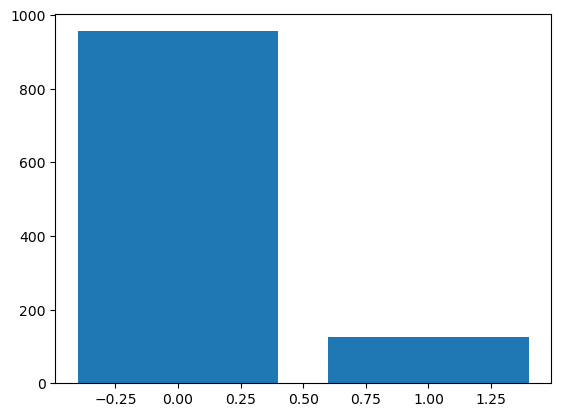

In [6]:
# IL DATASET E' BILANCIATO?
N, m = df.shape

target = df["classe"]
classes = target.value_counts()
#così in classes ho una series con da un lato le classi, dall'altro le cardinalità
print(classes)
percentages = []
labels = classes.index
data = classes.iloc
for el in classes:
  percentages.append(el/N*100)

print(f"Queste sono le percentuali di ogni classe:\n{percentages}.")
plt.bar(labels, data)



# Evito di usare lo smoothing perchè le prestazioni senza smoothing risultano essere più che soddisfacenti.

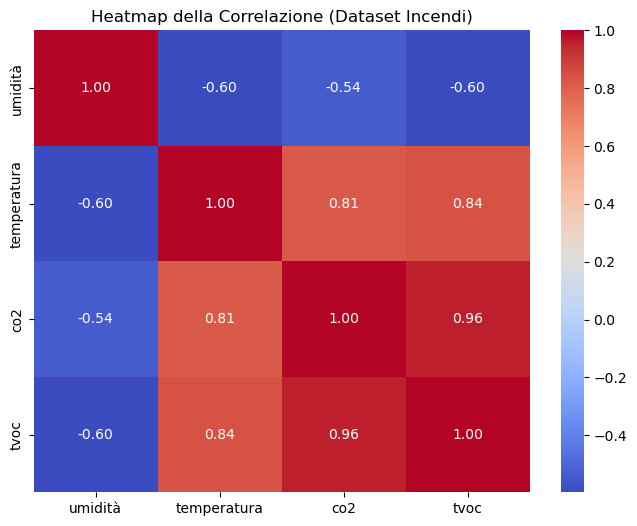

Feature eliminate: ['tvoc']


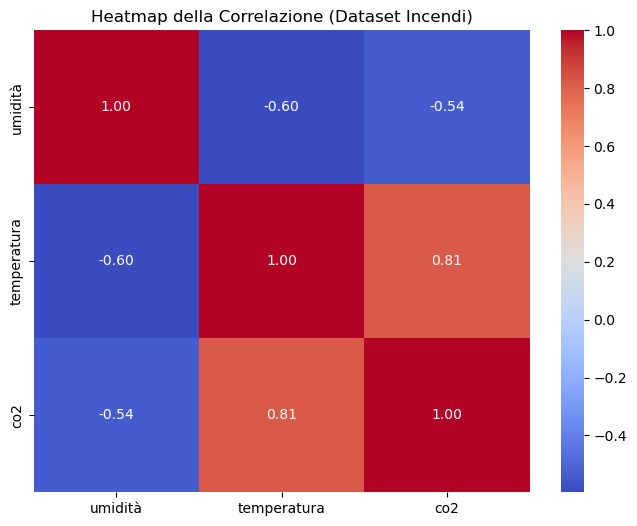

In [7]:
import seaborn as sns
import numpy as np

df_no_target = df.drop(columns=['classe'])

corr = df_no_target.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap della Correlazione (Dataset Incendi)")
plt.show()



corr_matrix = df_no_target.corr().abs()

# Maschera triangolare per non duplicare
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Trova le colonne con correlazione > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# Rimuovi le colonne ridondanti
df_reduced = df_no_target.drop(columns=to_drop)

print("Feature eliminate:", to_drop)



corr = df_reduced.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap della Correlazione (Dataset Incendi)")
plt.show()

Ho poche feature e le reti di dipendenza tra co2 e tvoc possono essere informative per la classe 1, che appare più eterogenea in quanto si è notato come la deviazione standard sia parecchio alta. Decido allora di tenere le features.

Proprio per le poche features non ho bisogno di algoritmi di riduzione di dimensionalità (PCA, SVG), perchè non ne trarrei un vantaggio apprezzabile in termini di computazione.

L'overfitting è poco probabile perchè ho molti più dati che feature e la ridondanza non incrementa in maniera rilevante la complessità (varianza) senza aggiungere vera informazione. Inoltre, scegliendo meccanismi di regolarizzazione adeguata posso ridurre ancora di più il rischio per metodi come KNN.

# 1.2 PLOT DEL DATASET

Uso un algoritmo di dimensione della dimensionalità (PCA) per visualizzare la struttura proiettata del dataset in un grafico 2D, in modo da determinare se si tratta di un dataset linearmente separabile, e quindi compatibile con kernel lineari (SVC lineari, logistic regression).

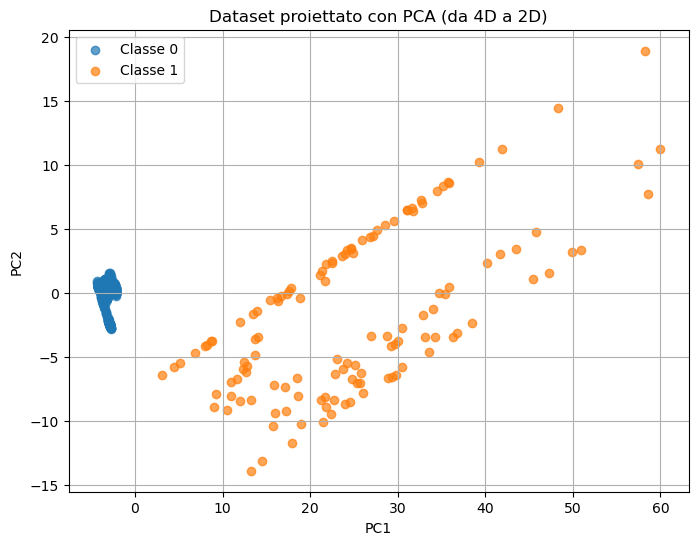

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

X = df.drop("classe", axis=1)
Y = df.loc[:, "classe"]

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# 2. Applichiamo PCA per ridurre a 2 dimensioni
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)            # qui avviene la proiezione del dataset

# 3. Visualizzazione
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[Y == 0, 0], X_pca[Y == 0, 1], label='Classe 0', alpha=0.7)
plt.scatter(X_pca[Y == 1, 0], X_pca[Y == 1, 1], label='Classe 1', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Dataset proiettato con PCA (da 4D a 2D)')
plt.legend()
plt.grid(True)
plt.show()

Si può notare come le due classi (blu e arancione) siano ben distinte le une dalle altre. Inoltre, sono distribuite seguendo un certo pattern e non sono messe a caso, confermando ancora una volta la correlazione tra alcune features.

Questo mi aiuta anche a capire quali classificatori posso escludere a priori, come il classificatore Bayesiano, che come requisito per funzionare bene ha bisogno che tutte le features siano indipendenti e che non ci sia correlazione. Quindi, lo escludo subito.

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# 2.1 Modelli di apprendimento SUPERVISIONATO (SVM)

Ha l'obiettivo di trovare un iperpiano che divida i miei dati correttamente nelle classi per cui sono etichettati. Il piano obiettivo è quello che massimizza la distanza tra due punti significativi detti "vettori di supporto" (gli altri punti sono ininfluenti alla determinazione dell'iperpiano). Si può applicare sia per 
regressione che per classificazione.

Rappresenta una scelta sensata per il mio dataset perchè:
* Efficace per dataset "verticali", con molte osservazioni piuttosto che features
* Efficace in termini di memoria, nel caso volessi caricare il modello (che quindi risulterebbe molto leggero) su dispositivi embedded per il riconoscimento di incendi da remoto senza richiedere troppe risorse computazionali
* Adattabile a molte distribuzioni di dati grazie alla scelta del kernel

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop("classe", axis=1)
Y = df.loc[:, "classe"]

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=1/3, random_state=0, stratify= Y)            

# aumento l'efficacia dello scaling Robust preparando le colonne con molti outlier, accorciandole grazie ad un ulteriore scaling logaritmico

X['co2'] = np.log1p(X['co2'])  # log1p(x) = log(1+x), sicuro anche per x=0
X['tvoc'] = np.log1p(X['tvoc'])

scaler = RobustScaler()
x_train = scaler.fit_transform(x_train)     # Fit e transform sul training
x_test = scaler.transform(x_test)           # Solo transform sul test


# controllo se stratify ha davvero mantenuto le proporzioni
print("Controllo proporzioni:")
print("NO incendio: ", sum(y_test == 0))
print("SI incendio: ", sum(y_test == 1))

# addestro il modello
clf = SVC(kernel="linear", random_state=0, tol=1e-5, cache_size=1000, shrinking=False)
clf.fit(x_train, y_train)

# effettuo previsioni sul training set e sul test set
t_preds = clf.predict(x_train)
preds = clf.predict(x_test)

Controllo proporzioni:
NO incendio:  319
SI incendio:  42


SVM è un metodo sensibile alla scala (a differenza di alberi decisionali o XGBoost). Di conseguenza, serve scegliere uno scaler appropriato per evitare che durante i conti ci siano dei dati trascurati perchè in valore assoluto poco impattanti rispetto agli altri.
Tra le possibili scelte sono presenti:
* StandardScaler        - centra la media a 0 e deviazione standard a 1
* MinMaxScaler          - scala tutto tra 0 e 1     (utile se servono solo valori positivi)
* RobustScaler          - come lo standard ma usa la mediana al posto della media ---> resistenza maggiore agli outliers
* Scaling Logaritmico   - mantiene quasi invariati i valori piccoli mentre "accorcia" di gran lunga quelli estremamente grandi

In questo caso ho scelto il Robust proprio per la sua resistenza agli outlier, rilevati nei passi precedenti. In questo caso ho voluto essere più preciso: ho ridotto logaritmicamente le colonne in cui sono presenti outliers
come la tvoc e la co2 per rendere più efficace lo scaling.

Il parametro stratify permette di non fare uno shuffle e basta, ma uno che mantiene conto di y, quindi lo sbilanciamento iniziale viene mantenuto sia nella parte train che nella parte test in proporzione. Permette di mantenere la stessa differenza percentuale del vero e del falso.

Senza stratify, avrei rischiato:
* Squilibri tra classi nel train e test set;
* Addirittura assenza di una classe nel test set, specialmente se una classe è rara.

In [10]:
print("Accuratezza nel training: {}".format(accuracy_score(y_train, t_preds)))
print("Accuratezza nel test: {}".format(accuracy_score(y_test, preds)))

Accuratezza nel training: 1.0
Accuratezza nel test: 1.0


In [11]:
print("Classification Report training")
print(classification_report(y_train, t_preds))

print("Classification Report test")
print(classification_report(y_test, preds))

Classification Report training
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       637
           1       1.00      1.00      1.00        85

    accuracy                           1.00       722
   macro avg       1.00      1.00      1.00       722
weighted avg       1.00      1.00      1.00       722

Classification Report test
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       319
           1       1.00      1.00      1.00        42

    accuracy                           1.00       361
   macro avg       1.00      1.00      1.00       361
weighted avg       1.00      1.00      1.00       361



In [12]:
print("Confusion Matrix training")
print(confusion_matrix(y_train, t_preds))

print("Confusion Matrix test")
print(confusion_matrix(y_test, preds))

Confusion Matrix training
[[637   0]
 [  0  85]]
Confusion Matrix test
[[319   0]
 [  0  42]]


Stampa dei vettori di supporto, ovvero i punti più vicini all'iperpiano. Utile per determinare il margine, che ne rappresenta la distanza. Più grande è il margine e minore è l'errore nella classificazione. Non a caso si 
tratta di un valore da massimizzare, il margine. Eventualmente, si può parlare di soft margin nel momento in cui vogliamo aggiungere una variabile di tolleranza nel calcolo della distanza, per facilitare la convergenza del
modello.

In [13]:

print("VETTORI DI SUPPORTO")
print(clf.support_vectors_)
print("\nI vettori di supporto sono {}".format(len(clf.support_vectors_)))

print("\n\n Dati associati ai vettori di supporto")
print(df.iloc[clf.support_])

VETTORI DI SUPPORTO
[[ 0.          0.88888889  0.31887599  0.80068143]
 [ 1.55223881  3.11111111 -1.33903482 -0.59284497]
 [-1.43283582  8.66666667  0.78802688  2.9165247 ]]

I vettori di supporto sono 3


 Dati associati ai vettori di supporto
     umidità  temperatura   co2  tvoc  classe
181       57         23.3   446     7       0
561       59         23.7  1637   279       0
147       40         23.1   569    25       0


Ogni peso mi fa capire quanto conta una feature nel determinare la separazione. E' un vettore normale all'iperpiano. L'intercetta è la quota (il bias), che trasla il mio iperpiano nello spazio senza inclinarlo.

In [14]:
print("Intercetta: {}".format(clf.intercept_))
print("Pesi: {}".format(clf.coef_))

Intercetta: [-1.2985768]
Pesi: [[-0.10231628  0.20099978  0.071765    0.12117969]]


Per limitare ancora di più l'overfitting, garantendo comunque i migliori risultati ottenibili, effettuo una grid search per il tuning dei parametri e uno Stratified Cross Validation per ottenere il modello finale che abbia tenuto conto di più variabili possibili.

Fitting 5 folds for each of 576 candidates, totalling 2880 fits

Migliori parametri trovati:
{'clf__C': 0.1, 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'linear', 'clf__shrinking': True, 'clf__tol': 0.0001}

Migliore accuratezza media in cross-validation:
1.0

Classification report sul dataset completo (per reference):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       287
           1       1.00      1.00      1.00        38

    accuracy                           1.00       325
   macro avg       1.00      1.00      1.00       325
weighted avg       1.00      1.00      1.00       325

Confusion Matrix:
[[287   0]
 [  0  38]]
Accuracy complessiva: 1.0


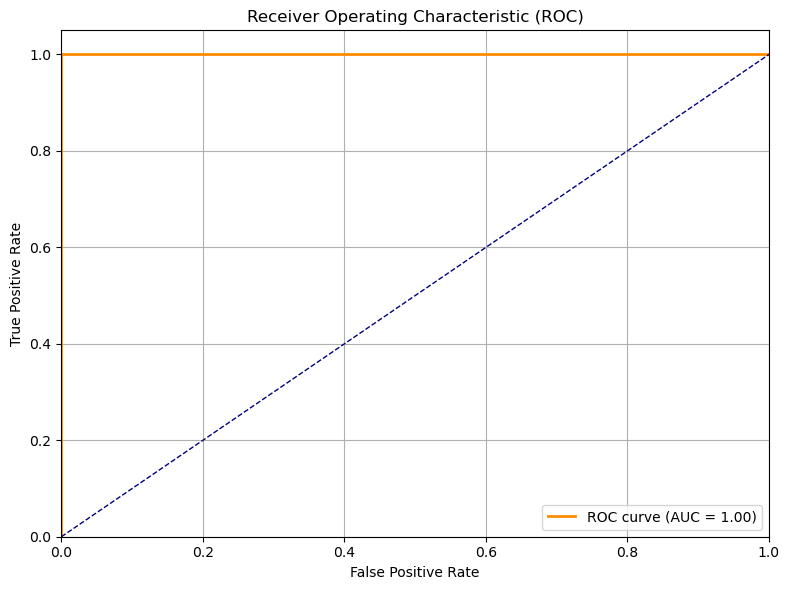

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV           # un LOO è da escludere... troppe osservazioni. A maggior ragione con una GridSearch. Il guadagno di stima di errore sarebbe troppo infimo rispetto al tempo che ci ho messo per ottenerlo.
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Preparo X e Y
X = df.drop("classe", axis=1).copy()
Y = df["classe"].copy()

# Creo una trasformazione logaritmica custom per co2 e tvoc
def log_transform(X):
    X = X.copy()
    X['co2'] = np.log1p(X['co2'])
    X['tvoc'] = np.log1p(X['tvoc'])
    return X

# Pipeline con:
# 1. Trasformazione log
# 2. Scaling robusto
# 3. Classificatore SVM
pipeline = Pipeline([
    ('log', FunctionTransformer(log_transform)),
    ('scaler', RobustScaler()),
    ('clf', SVC(probability=True))
])

# Griglia di iperparametri da esplorare
param_grid = {
    'clf__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],                # il kernel serve a determinare lo spazio delle features in cui il classificatore cerca di separare le classi
    'clf__C': [0.1, 0.01, 0.001, 1, 10, 100],                           # valori alti ----> il modello diventa molto rigido, rischiando overfitting.         Valori bassi ----> modello tollerante, generalizza meglio.
    'clf__gamma': ['scale', 'auto'],                                    # mi dice quanto è vicino un punto per influenzare una decisione        (scale: reciproco del numero di features * varianza). valori alti : curva stretta e rischio overfitting. valori basi: decisioni più morbide e generalizzate.
    'clf__degree': [2, 3, 4],                                           # solo rilevante per kernel='poly'
    'clf__shrinking': [True, False],                                    # smette o meno di considerare alcuni dati se durante il training si accorge che non influenzano più di tanto la determinazione del margine. Utile per velocizzare il training senza toccare le proprietà del modello
    'clf__tol': [1e-4, 1e-5]                                            # è la soglia di convergenza del modello (non deve per forza scendere sempre a 0 ma ci si può avvicnare arbitrariamente). (tolleranza)
}

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

# Definizione della Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)             # 5 partizioni. rimescolamento per evitare bias dovuti a dati ordinati cronologicamente o per classi (overfitting). Random state fissato per mescolare con un seme definito

# GridSearchCV con valutazione incrociata
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=2)          # massimo parallelismo e "commento" moderato durante la ricerca dei parametri
grid.fit(x_train, y_train)

# Risultati migliori
print("\nMigliori parametri trovati:")
print(grid.best_params_)

print("\nMigliore accuratezza media in cross-validation:")
print(grid.best_score_)

# Valutazione finale sul modello migliore
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print("\nClassification report sul dataset completo (per reference):")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy complessiva:", accuracy_score(y_test, y_pred))


# CURVA DI ROC: quanti falsi allarmi ci sono? Mi basta guardare in alto a sinitra. Più AUC si avvicina ad 1 e più il modello è in grado di discriminare tra le due classi.

# Calcolo delle probabilità previste dal miglior modello
y_proba = best_model.predict_proba(x_test)[:, 1]

# Calcolo della curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot della curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Date le ottime prestazioni capisco subito che il dataset è stato ben scalato e pulito. Inoltre, capisco anche che avendo il miglior modello un kernel SVC lineare, vuol dire che le classi sono linearmente separabili.

# 2.2 KNN (K-Nearest-Neighbours)

Anche KNN è sensibile alla scala e agli outliers, quindi dovrò usare un meccanismo di scaling simile a quanto fatto con SVC. Essendo un modello non lineare, e regolarizzando con L2 o L1 che diluiscono l'impatto
delle feature correlate, posso diminuire le chances di overfitting, anche aiutandomi con una cross validation.

Dato un oggetto x, bisogna trovare il k-esimo più similare oggetto a x. Per fare questo, mi servono k vicini e una misura per misurare la distanza o la similarità tra un elemento e un altro. Alla fine, il punto del test verrà classificato in base alla maggioranza delle etichette dei primi k vicini considerati.

In [16]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np


# Preparo X e Y
X = df.drop("classe", axis=1).copy()
Y = df["classe"].copy()

# Trasformazione log per co2 e tvoc
def log_transform(X):
    X = X.copy()
    X['co2'] = np.log1p(X['co2'])
    X['tvoc'] = np.log1p(X['tvoc'])
    return X

# Pipeline: log -> scaler -> KNN
pipeline = Pipeline([
    ('log', FunctionTransformer(log_transform)),
    ('scaler', RobustScaler()),
    ('clf', KNeighborsClassifier())
])

# Griglia di iperparametri per KNN
param_grid = {
    'clf__n_neighbors': [21, 23, 33, 35, 37, 41],               # numero di vicini       (un numero piccolo cattura bene i dettagli, ma è sensibile e rischia overfitting. Un alto numero tende a generalizzare troppo aumentando in maniera rovinosa il bias). Uso numeri dispari per evitare pareggi nelle classificazioni. Ho usato la regola della radice per determinare l'intervallo dei vicini che è più appropriato scegliere per il mio dataset
    'clf__weights': ['distance', 'uniform'],           # peso uniforme o inversamente proporzionale alla distanza
    'clf__metric': ['euclidean', 'manhattan'],          # metrica di distanza
    'clf__algorithm': ['brute', 'ball_tree', 'auto', 'kd_tree']         # impiegano un numero uguale o inferiore di confronti di distanza per ottenere un risultato di classificazione più velocemente
}

# Cross-validation stratificata
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Grid search con validazione incrociata
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=2)
grid.fit(x_train, y_train)

# Migliori parametri
print("\nMigliori parametri trovati:")
print(grid.best_params_)

print("\nMigliore accuratezza media in cross-validation:")
print(grid.best_score_)

# Valutazione sul dataset completo
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print("\nClassification report sul dataset completo:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy complessiva:", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 96 candidates, totalling 480 fits

Migliori parametri trovati:
{'clf__algorithm': 'brute', 'clf__metric': 'euclidean', 'clf__n_neighbors': 21, 'clf__weights': 'distance'}

Migliore accuratezza media in cross-validation:
1.0

Classification report sul dataset completo:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       287
           1       1.00      1.00      1.00        38

    accuracy                           1.00       325
   macro avg       1.00      1.00      1.00       325
weighted avg       1.00      1.00      1.00       325

Confusion Matrix:
[[287   0]
 [  0  38]]
Accuracy complessiva: 1.0


# 2.3 RETE NEURALE: MLP (Multi Layer Perceptron)

E' un modello di classificazione che cerca di emulare il comportamento del cervello umano. Usato maggiormente nel deep learning. Il modello è composto da tanti neuroni artificiali (Perceptroni) che ricevono dati, li trasformano e li trasmettono ai rispettivi vicini per ottenere un risultato di classificazione (binaria in questo caso). Per ogni input è prevista una unità di elaborazione con cui questi sono pesati in base a quanto sono importanti per il compito che deve essere eseguito. I pesi rappresentano la forza della connessione (sono dei numeri).

Attraverso una funzione di attivazione, l'output viene calcolato in base alla somma pesata dei dati ricevuti e al filtraggio di tale funzione. Un esempio è la ReLU (Rectified Linear Unit), che trasmette l'input se questo è positivo, altrimenti lo mette a 0. Alla fine, l'output sarà dato dall'output della funzione di attivazione + un bias.

Per rendere il modello responsivo a mano a mano che l'informazione passa nei neuroni, i relativi pesi possono essere aggiornati, per migliorare le previsioni future. Questo viene fatto attraverso meccanismi di propagazione.
Nel caso di MLP, si utilizza un meccanismo di propagazione in avanti (FNN) per far passare i dati fino all'ultimo livello che poi produrrà la predizione. Il meccanismo di aggioranamento dei pesi lo fa la backpropagation, che utilizza il risultato di un neurone esterno per ottimizzare i valori degli altri partendo dal layer di output fino ad arrivare a quello di input.

Infatti, l'errore dell'ultimo layer viene propagato in quelli più interni, si calcola il gradiente della funzione di errore rispetto ad ogni peso, e i pesi vengono riaggiornati tramite gradient descent o altre varianti (es. adam, lbfgs), quindi moltiplicando il valore del gradiente per il learning rate e sottraendo il risultato al singolo peso.

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix


# Definisco il modello base
mlp = MLPClassifier(random_state=42, max_iter=500)          # 500 epoche, learning rate di default impostato dalla funzione di libreria

# Parametri da provare con GridSearch
param_grid = {
    'hidden_layer_sizes': [
        (50,), (100,), (150,),
        (100, 50), (150, 100),
        (150, 100, 50), (200, 150, 100)
    ],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['sgd', 'adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],  # regolarizzazione L2: penalizza pesi grandi evitando overfitting riducendoli quadraticamente (non portandoli necessariamente a 0 come fa L1)
    'learning_rate': ['constant', 'adaptive']       # con adaptive, si riduce se il modello smette di migliorare
}

from sklearn.model_selection import train_test_split

X_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)


# Cross-validation stratificata a 5 fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit (ricerca dei parametri migliori)
grid_search.fit(X_train, y_train)

print("Migliori parametri trovati:")
print(grid_search.best_params_)
print(f"Miglior accuracy in CV: {grid_search.best_score_:.4f}")

# Predizioni usando il miglior modello su un test set:

best_mlp = grid_search.best_estimator_

y_pred = best_mlp.predict(x_test)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))


# Matrice di confusione
print("Matrice di Confusione:")
print(confusion_matrix(y_test, y_pred))


Fitting 5 folds for each of 378 candidates, totalling 1890 fits
Migliori parametri trovati:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'solver': 'sgd'}
Miglior accuracy in CV: 1.0000
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       287
           1       1.00      1.00      1.00        38

    accuracy                           1.00       325
   macro avg       1.00      1.00      1.00       325
weighted avg       1.00      1.00      1.00       325

Matrice di Confusione:
[[287   0]
 [  0  38]]


---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# 3.1 Apprendimento NON SUPERVISIONATO (K-Means)

L'apprendimento non supervisionato cerca di raggruppare osservazioni considerate simili sotto specifici cluster, che le fanno rientrare sotto una unica categoria. Non ci sono variabili target a cui fare riferimento.

In questo caso, ho usato un algoritmo di Partizionamento chiamato K-Means, che si basa su determinazione di centroidi, dopo aver passato come parametro il numero di cluster a cui voglio arrivare. Questo mi è comodo, perchè essendo una classificazione binaria, so già che il modello deve produrre esattamente due cluster; evitando il rischio che possa produrne di più in maniera incontrollata.

Il modello che ho scelto minimizza la somma delle distanze al quadrato tra i singoli punti e il centroide scelto. A mano a mano che si va avanti, si cerca di minimizzare un parametro detto inerzia, che quantifica lo sforzo di raggiugimento di un generico punto dal centroide scelto. Più l'inerzia è alta, meno denso è il cluster e quindi tende ad essere meno accurato. Nel metodo fit del KMeans, il centroide viene ricalcolato per minimizzare l'inerzia calcolata all'iterazione precedente.

Lo svantaggio dell'inerzia è che non tiene conto della distanza inter-cluster. L'ideale sarebbe avere cluster compatti e ben separati tra di loro.

Essendo che il mio dataset dispone però delle labels, posso usare l'indice di Rand aggiustato (che misura la proporzione labels vere - labels predette) per darmi un'accuratezza migliore della silhouette o dell'inerzia, come se fosse un'accuracy supervisionata.

Per tenere conto anche della bontà di separazione inter-cluster, implemento le relative metriche.

Inerzia (SSE): 22172.34
Silhouette Score: 0.893
Adjusted Rand Index: 0.919
Distanza tra centroidi: 30.51
Single linkage (min): 1.06
Complete linkage (max): 65.24
Average linkage: 31.25


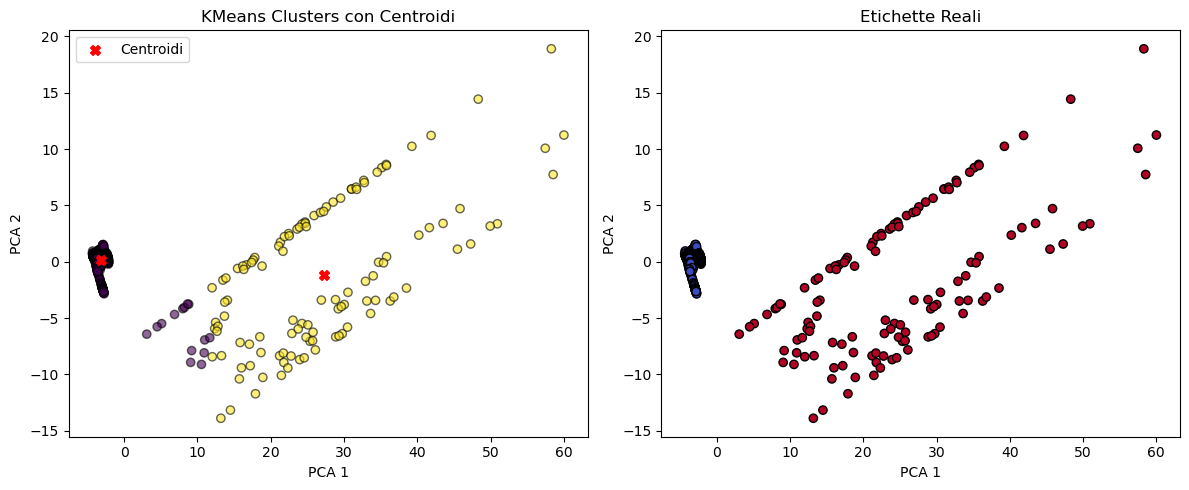

In [18]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import cdist
import numpy as np

# 1. Normalizzazione robusta
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA per visualizzazione
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Clustering con KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans.fit(X_scaled)
labels = kmeans.labels_

# 4. Metriche classiche
inertia = kmeans.inertia_
sil_score = silhouette_score(X_scaled, labels)
ari = adjusted_rand_score(Y, labels)

# 5. Centroidi e distanze inter-cluster
centroids = kmeans.cluster_centers_
inter_centroid_distance = np.linalg.norm(centroids[0] - centroids[1])

# 6. Distanze tra punti appartenenti a cluster diversi
cluster_0 = X_scaled[labels == 0]
cluster_1 = X_scaled[labels == 1]
inter_cluster_distances = cdist(cluster_0, cluster_1)

# Linkage
min_dist = inter_cluster_distances.min()        # Single linkage
max_dist = inter_cluster_distances.max()        # Complete linkage
avg_dist = inter_cluster_distances.mean()       # Average linkage

# 7. Stampa metriche
print(f"Inerzia (SSE): {inertia:.2f}")
print(f"Silhouette Score: {sil_score:.3f}")
print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Distanza tra centroidi: {inter_centroid_distance:.2f}")
print(f"Single linkage (min): {min_dist:.2f}")
print(f"Complete linkage (max): {max_dist:.2f}")
print(f"Average linkage: {avg_dist:.2f}")

# 8. Visualizzazione
plt.figure(figsize=(12, 5))

# KMeans cluster + centroidi
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', edgecolor='k', alpha=0.6)
# Proiettiamo i centroidi nello spazio PCA
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            marker='X', c='red', s=50, label='Centroidi')
plt.title("KMeans Clusters con Centroidi")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()


# Etichette reali
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y, cmap='coolwarm', edgecolor='k')
plt.title("Etichette Reali")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()


# 3.2 GMM (Gaussian Mixture Model) e Clustering Spettrale

Si tratta di altri due metodi di apprendimento per l'analisi non supervisionata. GMM è un modello probabilistico che assume che i dati siano generati da una miscela di diverse distribuzioni gaussiane. Esso stima i parametri di tale distribuzione (media e varianza), e il peso di ciascuna componente. Questo viene fatto calcolando la matrice di covarianza di ciascuna feature (che da sola determina l'orientamento e la forma della distribuzione). Essendo che cattura le relazioni lineari tra più variabili casuali, risulta perfetto per adattarsi alla forte correlazione di alcune feature, che si è palesata soprattutto nella parte di preprocessamento.

Il clustering spettrale, invece, è il migliore che è stato trattato per classificare cluster dalle forme complesse e lontane dalla sfericità. Ho pensato che potesse risultare utile per come sono messi i puntini arancioni, ed in effetti le sue prestazioni sono ottime. Esso sfrutta la struttura degli autovalori e autovettori di una matrice derivata da un grafo di dati precedentemente costruito. I pesi sugli archi di ciascun ramo nel grafo rappresentano la similarità tra punti. Opera in questo modo:
* Costruisce il grafo dei dati
* Calcola il Laplaciano del grafo
* Estrae gli autovettori (pesi) dalla matrice ottenuta dal grafo
* calcola gli autovalori (che spiegano come la varianza viene distribuita nelle varie classi)
* Usa il K-Means sul nuovo spazio ottenuto (ridotto rispetto a quello originale)

c:\Users\aless\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



--- Gaussian Mixture Model ---
Silhouette Score: 0.887
Adjusted Rand Index: 1.000
Distanza tra centroidi: 28.61
Single linkage (min): 7.31
Complete linkage (max): 65.24
Average linkage: 29.43

--- Clustering Spettrale ---
Silhouette Score: 0.887
Adjusted Rand Index: 1.000
Distanza tra centroidi: 28.61
Single linkage (min): 7.31
Complete linkage (max): 65.24
Average linkage: 29.43


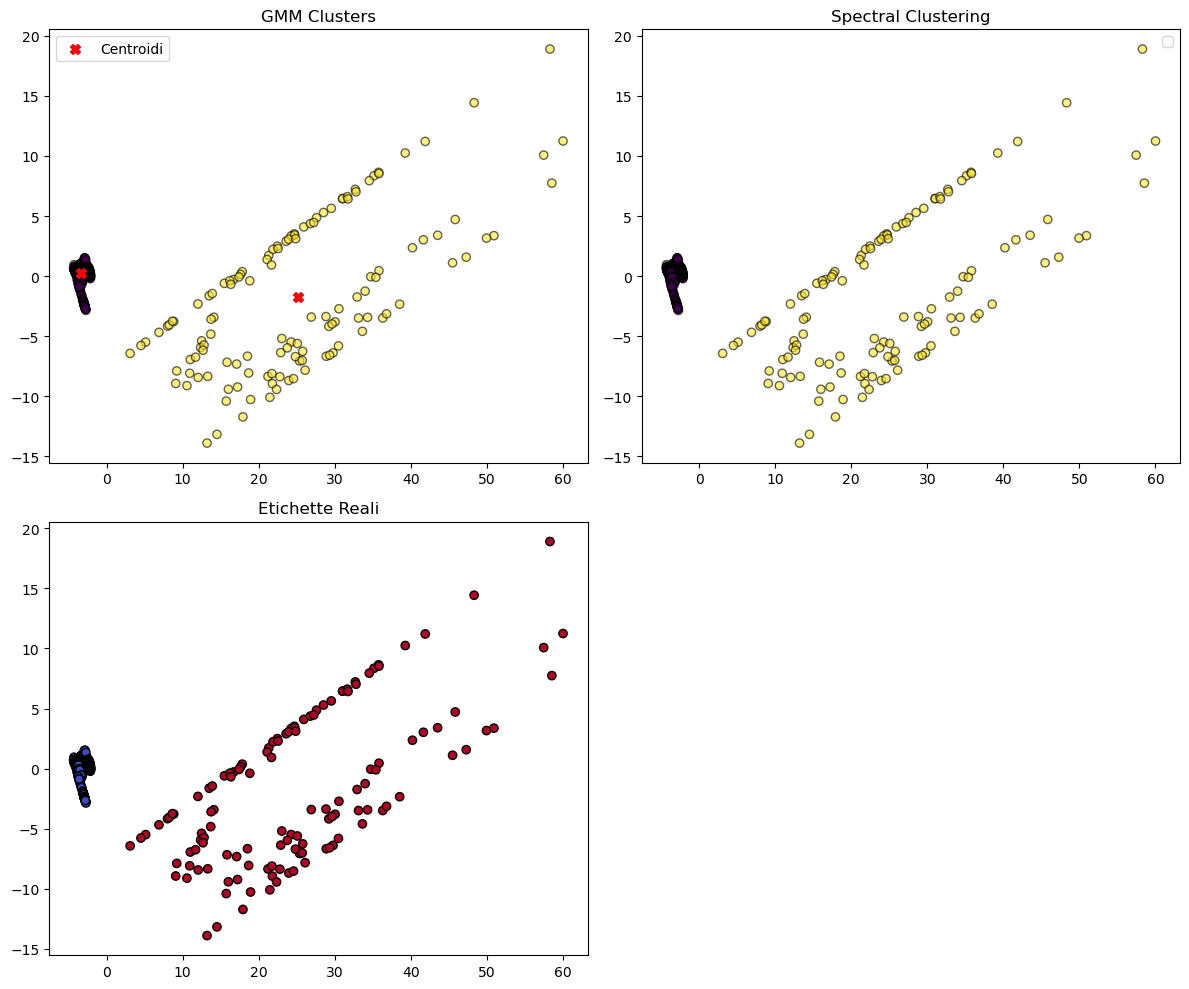

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import cdist
import numpy as np

# 1. Normalizzazione
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA per visualizzazione
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### --- GMM ---
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_centroids = gmm.means_

# Metriche GMM
gmm_sil = silhouette_score(X_scaled, gmm_labels)
gmm_ari = adjusted_rand_score(Y, gmm_labels)
gmm_inter = np.linalg.norm(gmm_centroids[0] - gmm_centroids[1])
gmm_inter_dist = cdist(X_scaled[gmm_labels == 0], X_scaled[gmm_labels == 1])
gmm_min = gmm_inter_dist.min()
gmm_max = gmm_inter_dist.max()
gmm_avg = gmm_inter_dist.mean()

### --- Clustering Spettrale ---
spec = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42, n_neighbors= 10)
spec_labels = spec.fit_predict(X_scaled)

# Metriche Spectral
spec_sil = silhouette_score(X_scaled, spec_labels)
spec_ari = adjusted_rand_score(Y, spec_labels)
# I centroidi non sono direttamente disponibili; usiamo il baricentro dei punti per approssimarlo
spec_centroids = np.array([X_scaled[spec_labels == i].mean(axis=0) for i in range(2)])
spec_inter = np.linalg.norm(spec_centroids[0] - spec_centroids[1])
spec_inter_dist = cdist(X_scaled[spec_labels == 0], X_scaled[spec_labels == 1])
spec_min = spec_inter_dist.min()
spec_max = spec_inter_dist.max()
spec_avg = spec_inter_dist.mean()

### --- Stampa metriche ---
print("\n--- Gaussian Mixture Model ---")
print(f"Silhouette Score: {gmm_sil:.3f}")
print(f"Adjusted Rand Index: {gmm_ari:.3f}")
print(f"Distanza tra centroidi: {gmm_inter:.2f}")       # Ward metric
print(f"Single linkage (min): {gmm_min:.2f}")
print(f"Complete linkage (max): {gmm_max:.2f}")
print(f"Average linkage: {gmm_avg:.2f}")

print("\n--- Clustering Spettrale ---")
print(f"Silhouette Score: {spec_sil:.3f}")
print(f"Adjusted Rand Index: {spec_ari:.3f}")
print(f"Distanza tra centroidi: {spec_inter:.2f}")
print(f"Single linkage (min): {spec_min:.2f}")
print(f"Complete linkage (max): {spec_max:.2f}")
print(f"Average linkage: {spec_avg:.2f}")

### --- Visualizzazione ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# GMM
axs[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', alpha=0.6, edgecolor='k')
gmm_pca_centroids = pca.transform(gmm_centroids)
axs[0, 0].scatter(gmm_pca_centroids[:, 0], gmm_pca_centroids[:, 1], marker='X', c='red', s=50, label='Centroidi')
axs[0, 0].set_title("GMM Clusters")
axs[0, 0].legend()

# Spectral
axs[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=spec_labels, cmap='viridis', alpha=0.6, edgecolor='k')
spec_pca_centroids = pca.transform(spec_centroids)
axs[0, 1].set_title("Spectral Clustering")
axs[0, 1].legend()

# Etichette vere
axs[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=Y, cmap='coolwarm', edgecolor='k')
axs[1, 0].set_title("Etichette Reali")

axs[1, 1].axis('off')  # Vuoto

plt.tight_layout()
plt.show()


In questo utilizzando metodi più pesanti notiamo che l'ARI raggiunge addirittura il valore massimo per il GMM, che effettivamente era il miglior candidato in quanto capace di catturare la correlazione tra feature e seguirla per modellare i cluster. Il clustering spettrale, invece, raggiunge le medesime prestazioni con una affinity di tipo nearest neighbors e invece si rivela fallimentare con un kernel rbf per costruire il grafo di similarità su cui basarsi.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# 4.1 Apprendimento SemiSupervisionato (Self Training)

Le metodologie di apprendimento semisupervisionata mettono insieme tecniche provenienti dall'analisi supervisionata e da quella non supervisionata. Infatti, simulerò un dataset con labels mancanti proprio per realizzare un dataset misto. La strategia del Self Training (il modello semisupervisionato che ho scelto) sarà quella di utilizzare un algoritmo supervisionato per rigenerare induttivamente le labels mancanti ed etichettare correttamente ogni osservazione del dataset. Alla fine, valuterò i risultati con alcune delle metriche viste in precedenza.

Generalization Error (test): 0.000
Adjusted Rand Index (test): 1.000


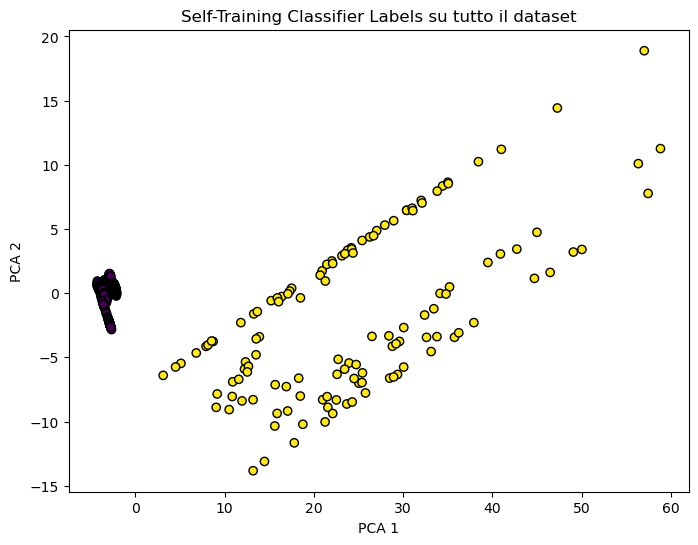

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, adjusted_rand_score

# 0. Divido il dataset in train e test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# 1. Normalizzazione robusta sui dati train e test (fit solo su train)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Simulo dati parzialmente etichettati nel train
rng = np.random.RandomState(42)                                                                             # generatore di numeri casuale con seed fissato per riproducibilità dei risultati
labels_train = -np.ones(len(Y_train))   # -1 -----> non etichettato                                         # creo un array lungo quanto Y_train, i cui elementi sono inizializzati tutti a -1 per simboleggiare che non conosco la classe
known_idx = rng.choice(len(Y_train), size=int(0.2*len(Y_train)), replace=False)                             # scelgo casualmente un 20% degli indici del dataset di training, per cui conosco l'etichetta
labels_train[known_idx] = Y_train.to_numpy()[known_idx]  # etichette note solo su subset                    # sostituisco a questi indici corrispondenti a labels_train quelle conosciute in Y_train, in modo da avere un 20% di osservazioni con l'etichetta e il resto con -1, etichetta sconosciuta

# 3. Modello base e self-training
base_clf = LogisticRegression(max_iter=1000)
self_training_clf = SelfTrainingClassifier(base_clf)
self_training_clf.fit(X_train_scaled, labels_train)

# 4. Predizioni su test
Y_pred = self_training_clf.predict(X_test_scaled)

# 5. Metriche
accuracy = accuracy_score(Y_test, Y_pred)
generalization_error = 1 - accuracy
ari = adjusted_rand_score(Y_test, Y_pred)

print(f"Generalization Error (test): {generalization_error:.3f}")
print(f"Adjusted Rand Index (test): {ari:.3f}")

# 6. Visualizzazione con PCA (train + test)
pca = PCA(n_components=2)
X_all_scaled = scaler.transform(X)
X_all_pca = pca.fit_transform(X_all_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_all_pca[:, 0], X_all_pca[:, 1], c=self_training_clf.predict(X_all_scaled), cmap='viridis', edgecolor='k')
plt.title("Self-Training Classifier Labels su tutto il dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


Ho usato una logistic regression per aiutarmi a ricreare le labels mancanti partendo da un sottoinsieme (20%). Il modello base viene addestrato solo con il 20% delle osservazioni labellate tramie logistic regression, che non ho usato durante l'analisi supervisionata. Il motivo sta nel fatto che la logistic regression, essendo sensibile a molte delle criticità del mio dataset, avrei dovuto normalizzare molto e stare attento ad usarla da sola sul dataset. Un approccio di pseudo-labelling mi è sembrato più sicuro da effettuare per questo algoritmo (ed effettivamente le prestazioni lo confermano).

Successivamente, il modello usa quello che ha imparato per ricostruire l'insieme completo delle labels (vere + pseudo etichettate). Alla fine, valuto l'accuratezza del modello con un ARI e un Generalization Error (complemento a 1 dell'accuracy) per stabilire, come ho fatto per il caso non supervisionato, la correttezza delle previsioni senza usare il plot dei due cluster.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# 5.0 Conclusioni

Se dovessi scegliere il migliore tra i metodi utilizzati per l'analisi e l'addestramento di modelli per questo dataset sugli incendi, la mia scelta andrebbe sicuramente per l'SVC, in quanto richiede basse risorse computazionali e di archiviazione, permettendo una implementazione stabile e flessibile anche in sistemi embedded (noti per le loro risorse limitate), che posso usare agevolmente per rilevare efficacemente incendi da remoto, installandoli ad esempio nelle abitazioni o nei laboratori di ricerca che ne richiedono l'uso.